Author: Gaurav Kumar  
Project: ESG Risk Intelligence Platform  
Tools Used: Python, Pandas, NumPy, Matplotlib  
Domain: ESG Analytics & Sustainability Intelligence

# ESG Risk Intelligence Platform
## Exploratory Data Analysis (EDA)

This notebook focuses on exploring environmental and sustainability indicators from the cleaned ESG dataset.

The objective of this analysis is to:
- identify global emission trends
- evaluate country-level sustainability patterns
- analyze greenhouse gas behavior
- understand environmental risk indicators
- generate business-oriented ESG insights

The analysis supports downstream:
- ESG risk scoring
- SQL analytics
- sustainability intelligence dashboards
- executive reporting

## Step 1 — Import Analytical Libraries

Python libraries were imported for:
- data analysis
- environmental trend exploration
- statistical evaluation
- ESG visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2 — Load Final ESG Dataset

The cleaned ESG dataset was imported for exploratory environmental and sustainability analysis.

In [3]:
esg_df = pd.read_csv(
    'final_esg_dataset.csv'
)

## Step 3 — Validate Dataset Structure

Initial validation was performed to confirm:
- dataset dimensions
- feature availability
- data types
- analytical readiness

In [4]:
esg_df.head()

,country,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,energy_per_capita,share_global_co2,temperature_change_from_ghg,total_ghg
0,Afghanistan,1950,7776180.0,9.421400e+09,0.084,0.011,0.021,0.063,0.0,7.879,481.209,0.001,0.001,19.869
1,Afghanistan,1951,7879343.0,9.692280e+09,0.092,0.012,0.026,0.066,0.0,7.973,481.209,0.001,0.001,21.069
2,Afghanistan,1952,7987784.0,1.001732e+10,0.092,0.011,0.032,0.060,0.0,8.073,481.209,0.001,0.001,22.094
3,Afghanistan,1953,8096703.0,1.063052e+10,0.106,0.013,0.038,0.068,0.0,8.186,481.209,0.002,0.001,23.256
4,Afghanistan,1954,8207954.0,1.086636e+10,0.106,0.013,0.043,0.064,0.0,8.305,481.209,0.002,0.001,24.251


In [5]:
esg_df.shape

(15045, 14)

In [6]:
esg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15045 entries, 0 to 15044
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      15045 non-null  object 
 1   year                         15045 non-null  int64  
 2   population                   15045 non-null  float64
 3   gdp                          15045 non-null  float64
 4   co2                          15045 non-null  float64
 5   co2_per_capita               15045 non-null  float64
 6   coal_co2                     15045 non-null  float64
 7   oil_co2                      15045 non-null  float64
 8   gas_co2                      15045 non-null  float64
 9   methane                      15045 non-null  float64
 10  energy_per_capita            15045 non-null  float64
 11  share_global_co2             15045 non-null  float64
 12  temperature_change_from_ghg  15045 non-null  float64
 13  total_ghg       

## Step 4 — Statistical Overview of ESG Indicators

Descriptive statistical analysis was conducted to understand:
- environmental distributions
- emission variability
- economic scale differences
- greenhouse gas behavior

In [7]:
esg_df.describe()

,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,energy_per_capita,share_global_co2,temperature_change_from_ghg,total_ghg
count,15045.000000,1.504500e+04,1.504500e+04,15045.000000,15045.00000,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000,15045.000000
mean,1987.833500,1.045273e+08,3.236263e+11,438.039107,4.28236,180.973227,159.638448,74.655780,139.255016,21110.319793,2.037629,0.019753,743.969183
std,21.482672,5.034136e+08,3.105837e+12,2264.417120,7.31930,977.060114,814.888942,420.245355,618.042719,29951.326384,9.730536,0.093202,3451.431436
min,1950.000000,1.776000e+03,5.543200e+07,0.000000,0.00000,0.000000,0.000000,0.000000,0.001000,0.000000,0.000000,-0.001000,-9.219000
25%,1969.000000,1.561183e+06,1.544460e+10,0.879000,0.39800,0.000000,0.629000,0.000000,1.936000,2074.009000,0.005000,0.000000,9.039000
50%,1988.000000,6.033296e+06,3.452829e+10,7.722000,1.75000,0.256000,3.935000,0.007000,9.253000,9163.633000,0.039000,0.001000,42.083000
75%,2006.000000,2.228490e+07,9.091082e+10,59.622000,5.93100,10.874000,26.810000,7.288000,34.064000,28982.496000,0.279000,0.004000,140.441000
max,2024.000000,8.161973e+09,1.301126e+14,38598.578000,364.79100,15805.254000,12470.596000,8009.828000,9498.914000,318559.688000,100.000000,1.678000,54433.398000


## Step 5 — Validate Dataset Integrity

Duplicate validation was performed to ensure that the ESG dataset contains unique country-year observations suitable for time-series analysis.

In [9]:
duplicate_count = esg_df.duplicated().sum()

print(
    f"Duplicate Records: {duplicate_count}"
)

Duplicate Records: 0


## Step 6 — Filter Aggregated Regional Records

The original dataset contains:
- countries
- continents
- income groups
- global aggregates

For country-level ESG analysis, aggregated regional records were removed to ensure analytical consistency and accurate country comparisons.

In [13]:
exclude_regions = [
    'World',
    'Asia',
    'Europe',
    'North America',
    'South America',
    'Africa',
    'European Union (27)',
    'High-income countries',
    'Upper-middle-income countries',
    'Lower-middle-income countries',
    'Low-income countries'
]

country_df = esg_df[
    ~esg_df['country'].isin(exclude_regions)
]

## Step 6 — Identify Major CO2 Emitting Countries

Country-level CO2 emissions were aggregated to identify the largest contributors to global carbon emissions.

This analysis supports:
- environmental benchmarking
- ESG risk identification
- sustainability impact evaluation

In [14]:
top_emitters = (
    country_df.groupby('country')['co2']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_emitters

country
United States     345245.064
China             282894.718
Russia            116542.840
Germany            66455.665
Japan              65597.832
India              64134.929
United Kingdom     40768.591
Canada             31292.046
Ukraine            29249.187
France             28365.665
Name: co2, dtype: float64

## Step 7 — Visualize Major Carbon Emitters

A comparative visualization was created to evaluate the countries contributing most significantly to global CO2 emissions.

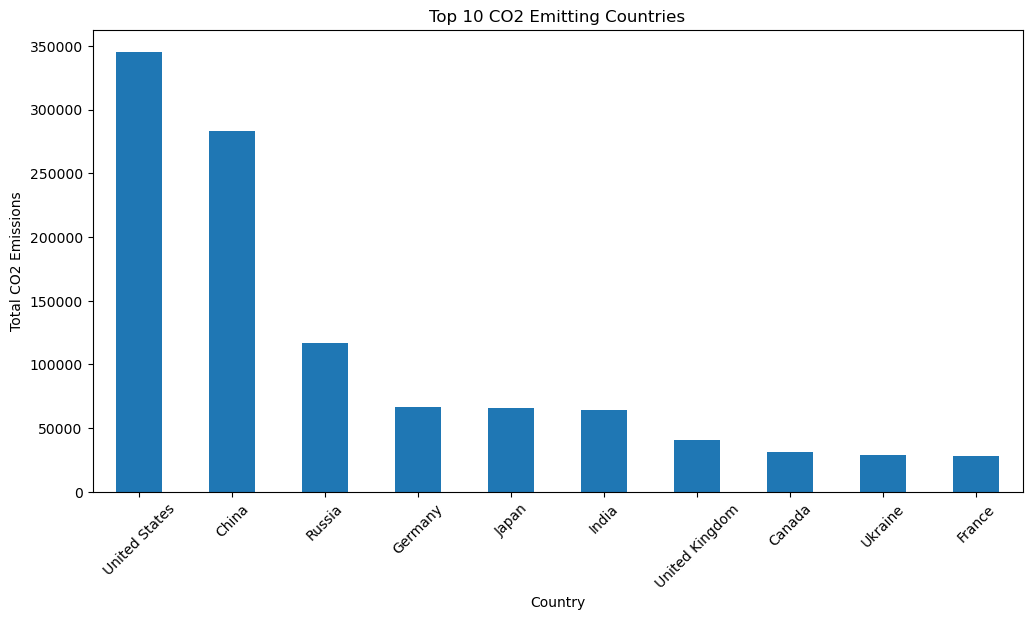

In [15]:
plt.figure(figsize=(12,6))

top_emitters.plot(kind='bar')

plt.title(
    'Top 10 CO2 Emitting Countries'
)

plt.xlabel('Country')
plt.ylabel('Total CO2 Emissions')

plt.xticks(rotation=45)

plt.show()

### Key Insight

The analysis indicates that a small group of countries contributes disproportionately to global carbon emissions.

High-emission countries represent elevated environmental and sustainability risks due to:
- industrial dependence
- fossil fuel consumption
- large-scale energy demand

These countries may require stronger sustainability policies and renewable energy transitions to reduce long-term ESG risk exposure.

## Step 8 — Analyze Global CO2 Emission Trends Over Time

Year-wise CO2 emissions were analyzed to evaluate long-term environmental trends and changes in global carbon output.

This analysis helps identify:
- industrial growth patterns
- long-term sustainability challenges
- climate-related emission acceleration
- historical environmental behavior

In [20]:
yearly_emissions = (
    country_df.groupby('year')['co2']
    .sum()
)

yearly_emissions.head()

year
1950    5856.962
1951    6284.463
1952    6374.950
1953    6551.573
1954    6687.849
Name: co2, dtype: float64

## Step 9 — Visualize Historical CO2 Emission Trends

A time-series visualization was created to evaluate how global CO2 emissions evolved across decades.

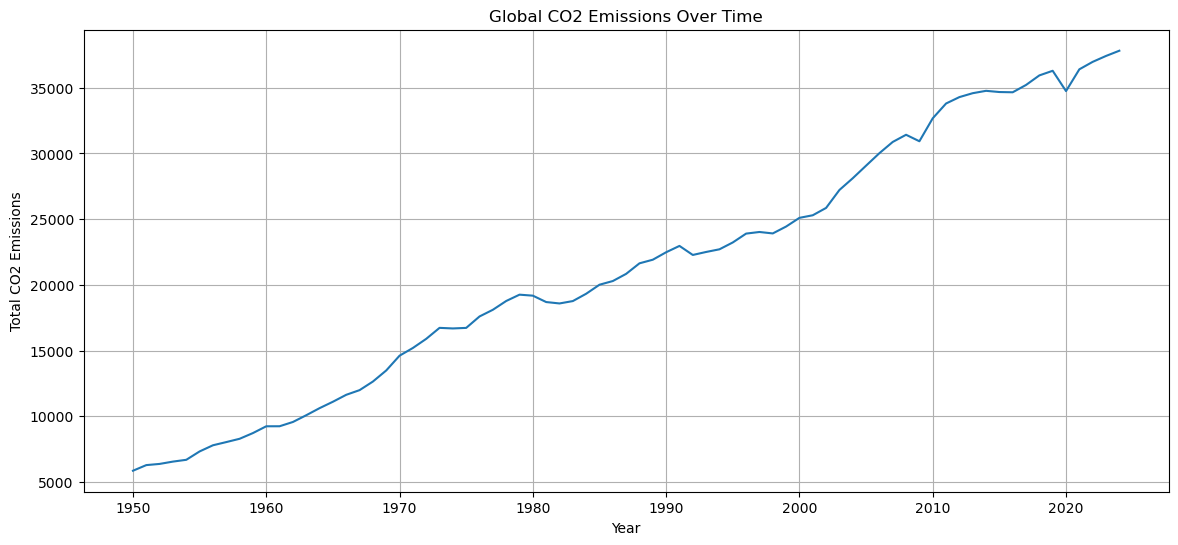

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_emissions.index,
    yearly_emissions.values
)

plt.title(
    'Global CO2 Emissions Over Time'
)

plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions')

plt.grid(True)

plt.show()

### Key Insight

The analysis reveals a strong long-term upward trend in global CO2 emissions between 1950 and 2024.

Major observations include:
- rapid industrial and economic expansion after the 1960s
- accelerated emission growth during globalization and industrialization periods
- temporary emission slowdowns during major economic disruptions
- sustained long-term environmental pressure despite climate-awareness initiatives

The sharp increase in emissions after 2000 highlights growing sustainability risks associated with:
- industrial energy demand
- fossil fuel dependency
- expanding global economic activity

The findings indicate that long-term emission growth remains a critical ESG and climate-related challenge.

## Step 10 — Analyze Fossil Fuel Emission Sources

Fossil fuel emission sources were analyzed to identify the primary contributors to global carbon emissions.

The analysis focuses on:
- coal emissions
- oil emissions
- gas emissions

Understanding emission source distribution is important for:
- sustainability policy analysis
- ESG risk evaluation
- energy transition assessment

In [21]:
fuel_emissions = {
    'Coal': country_df['coal_co2'].sum(),
    'Oil': country_df['oil_co2'].sum(),
    'Gas': country_df['gas_co2'].sum()
}

fuel_emissions

{'Coal': 665164.196, 'Oil': 572605.622, 'Gas': 274811.452}

## Step 11 — Visualize Fossil Fuel Emission Distribution

A comparative visualization was created to evaluate the relative contribution of major fossil fuel sources to total carbon emissions.

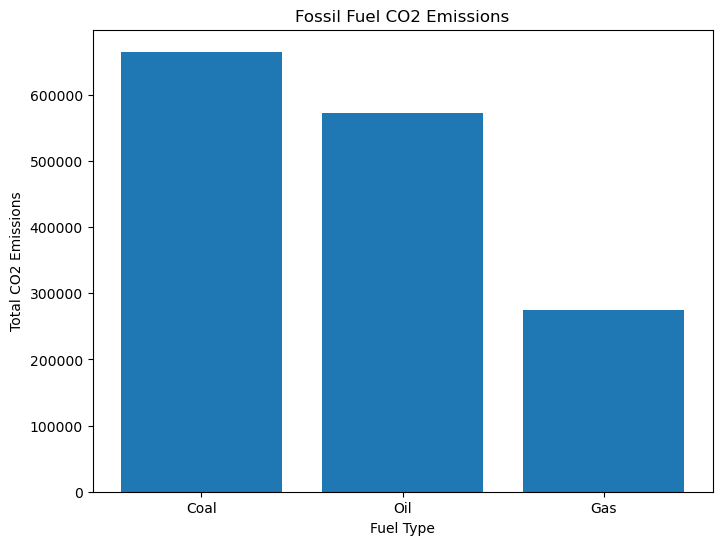

In [22]:
plt.figure(figsize=(8,6))

plt.bar(
    fuel_emissions.keys(),
    fuel_emissions.values()
)

plt.title(
    'Fossil Fuel CO2 Emissions'
)

plt.xlabel('Fuel Type')
plt.ylabel('Total CO2 Emissions')

plt.show()

### Key Insight

The fossil fuel analysis reveals that coal remains the dominant contributor to global carbon emissions, followed by oil and natural gas.

Major observations include:
- coal-intensive energy systems generate the highest environmental pressure
- oil continues to contribute significantly to long-term emissions growth
- natural gas emissions remain lower relative to coal and oil but still contribute substantially to greenhouse gas accumulation

The findings suggest that:
- reducing coal dependency may significantly lower global carbon emissions
- energy transition strategies should prioritize cleaner and renewable energy systems
- fossil fuel dependency remains a central driver of climate-related ESG risk

## Step 12 — Analyze Relationship Between GDP and CO2 Emissions

Economic growth and industrial expansion are closely associated with environmental impact.

A relationship analysis between GDP and CO2 emissions was conducted to evaluate how economic activity influences carbon output across countries.

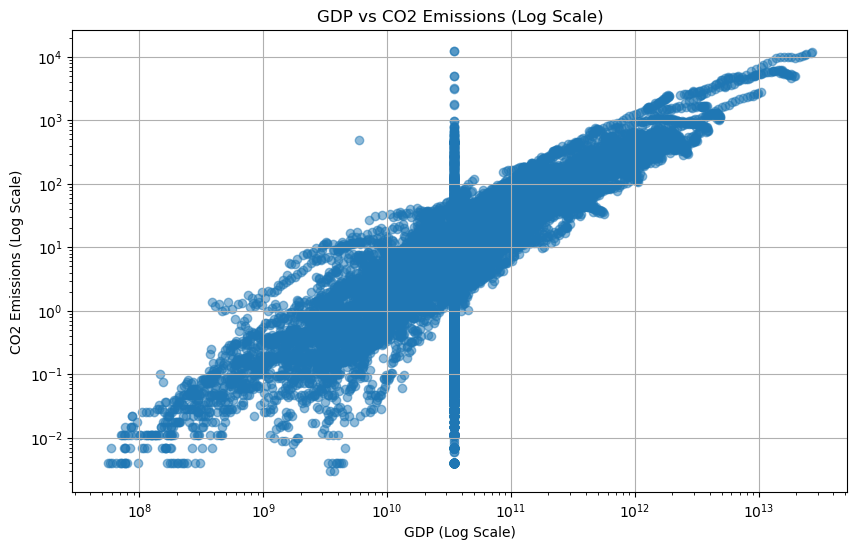

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(
    country_df['gdp'],
    country_df['co2'],
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.title(
    'GDP vs CO2 Emissions (Log Scale)'
)

plt.xlabel('GDP (Log Scale)')
plt.ylabel('CO2 Emissions (Log Scale)')

plt.grid(True)

plt.show()

### Key Insight

The analysis indicates a positive relationship between economic growth and carbon emissions.

Countries with higher GDP levels generally exhibit:
- greater industrial activity
- higher energy consumption
- increased fossil fuel dependency

The findings suggest that rapid economic expansion has historically been associated with rising environmental impact.

However, variations across countries also indicate that:
- some economies achieve higher GDP with relatively lower emissions
- energy efficiency and sustainability policies can influence environmental outcomes

The relationship highlights the importance of balancing economic growth with sustainable development and low-carbon energy transitions.

## Step 13 — Analyze Total Greenhouse Gas Emissions

Total greenhouse gas (GHG) emissions were analyzed to identify countries with the highest overall environmental impact.

Unlike CO2-only analysis, total GHG metrics provide broader ESG insight by incorporating multiple climate-related emission sources.

In [25]:
top_ghg_countries = (
    country_df.groupby('country')['total_ghg']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_ghg_countries

country
United States     438102.667
China             402818.166
Russia            178115.880
Brazil            151337.297
India             133942.699
Indonesia          85455.614
Germany            79627.968
Japan              71846.748
Canada             57498.135
United Kingdom     52996.078
Name: total_ghg, dtype: float64

## Step 14 — Visualize Major Greenhouse Gas Contributors

A comparative analysis was conducted to evaluate countries contributing most significantly to total greenhouse gas emissions.

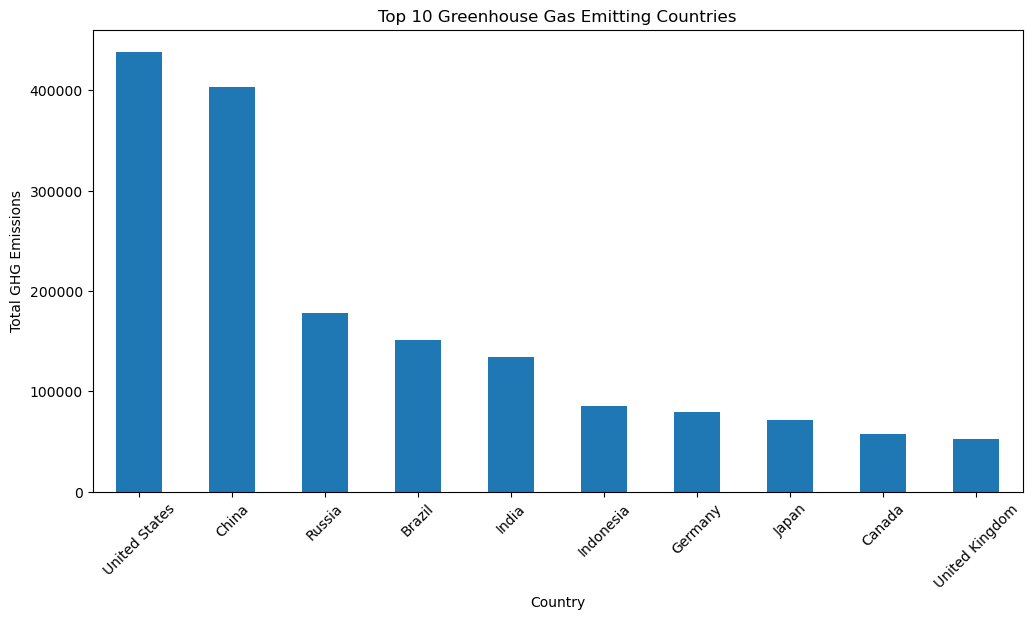

In [27]:
plt.figure(figsize=(12,6))

top_ghg_countries.plot(kind='bar')

plt.title(
    'Top 10 Greenhouse Gas Emitting Countries'
)

plt.xlabel('Country')
plt.ylabel('Total GHG Emissions')

plt.xticks(rotation=45)

plt.show()

### Key Insight

The greenhouse gas analysis reveals that environmental impact extends beyond CO2 emissions alone.

Major observations include:
- the United States and China remain dominant contributors to global greenhouse gas emissions
- emerging economies such as Brazil and Indonesia exhibit high overall GHG output despite lower industrial CO2 rankings
- agricultural activity, land-use changes, and methane emissions likely contribute significantly to total environmental impact

The findings highlight that:
- ESG risk assessment requires broader climate indicators beyond CO2 alone
- greenhouse gas analysis provides a more comprehensive view of sustainability risk
- developing economies may face rising climate-transition and environmental management challenges

The analysis demonstrates the importance of multidimensional environmental intelligence in ESG evaluation.

## Step 15 — Analyze CO2 Emissions Per Capita

Per-capita CO2 emissions were analyzed to evaluate environmental intensity relative to population size.

Per-capita analysis provides deeper ESG insight because it reflects:
- individual-level environmental impact
- energy efficiency
- sustainability behavior
- carbon intensity across economies

In [28]:
top_per_capita = (
    country_df.groupby('country')['co2_per_capita']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_per_capita


country
Qatar                   46.540040
United Arab Emirates    28.715773
Kuwait                  28.666040
Luxembourg              26.875707
Brunei                  20.081960
Bahrain                 19.292173
United States           18.455507
Saudi Arabia            15.857493
Trinidad and Tobago     15.701733
Canada                  15.216987
Name: co2_per_capita, dtype: float64

## Step 16 — Visualize Per-Capita Carbon Intensity

A comparative analysis was conducted to identify countries with the highest carbon emissions per person.

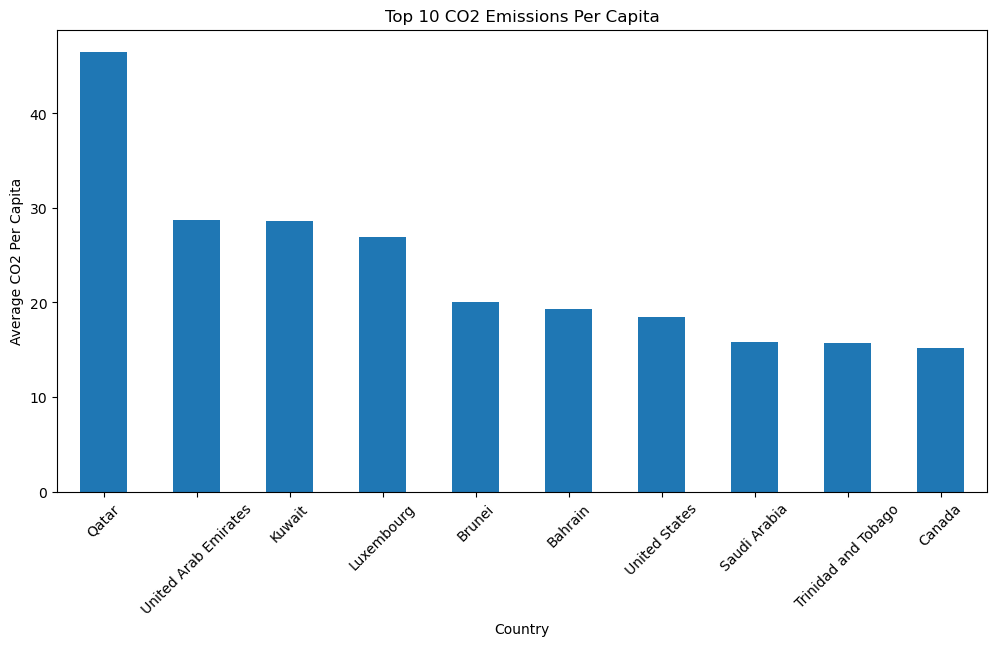

In [29]:
plt.figure(figsize=(12,6))

top_per_capita.plot(kind='bar')

plt.title(
    'Top 10 CO2 Emissions Per Capita'
)

plt.xlabel('Country')
plt.ylabel('Average CO2 Per Capita')

plt.xticks(rotation=45)

plt.show()

### Key Insight

Per-capita emission analysis reveals that several smaller economies exhibit extremely high carbon intensity despite lower total emissions.

Key observations include:
- Qatar, the United Arab Emirates, and Kuwait demonstrate exceptionally high per-capita carbon emissions
- energy-intensive industrial sectors and fossil fuel dependency contribute significantly to elevated carbon intensity
- developed economies such as the United States and Canada also maintain relatively high per-capita environmental impact

The findings suggest that:
- total emissions alone are insufficient for ESG evaluation
- per-capita metrics provide stronger insight into sustainability efficiency and environmental intensity
- high carbon-intensity economies may face increased climate-transition and regulatory risks in the future

This analysis highlights the importance of balancing economic development with sustainable energy consumption and carbon reduction strategies.

## Step 17 — Correlation Analysis of ESG Indicators

Correlation analysis was performed to evaluate relationships between environmental, economic, and sustainability-related indicators.

The objective of this analysis is to:
- identify strongly related ESG variables
- understand environmental dependencies
- support downstream ESG risk modeling
- detect key sustainability drivers

In [30]:
correlation_matrix = esg_df[
    [
        'gdp',
        'co2',
        'co2_per_capita',
        'coal_co2',
        'oil_co2',
        'gas_co2',
        'methane',
        'energy_per_capita',
        'temperature_change_from_ghg',
        'total_ghg'
    ]
].corr()

correlation_matrix

,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,energy_per_capita,temperature_change_from_ghg,total_ghg
gdp,1.000000,0.446264,0.049425,0.433962,0.404978,0.458254,0.388597,0.052735,0.444486,0.416584
co2,0.446264,1.000000,0.086762,0.969203,0.973502,0.949857,0.936649,0.080882,0.974769,0.980795
co2_per_capita,0.049425,0.086762,1.000000,0.066508,0.098494,0.105872,0.036909,0.737985,0.074050,0.061703
coal_co2,0.433962,0.969203,0.066508,1.000000,0.895465,0.859429,0.915446,0.054763,0.911427,0.954922
oil_co2,0.404978,0.973502,0.098494,0.895465,1.000000,0.951695,0.925433,0.094841,0.975225,0.962082
gas_co2,0.458254,0.949857,0.105872,0.859429,0.951695,1.000000,0.846008,0.112349,0.959858,0.908077
methane,0.388597,0.936649,0.036909,0.915446,0.925433,0.846008,1.000000,0.023598,0.953056,0.983857
energy_per_capita,0.052735,0.080882,0.737985,0.054763,0.094841,0.112349,0.023598,1.000000,0.071473,0.052584
temperature_change_from_ghg,0.444486,0.974769,0.074050,0.911427,0.975225,0.959858,0.953056,0.071473,1.000000,0.979500
total_ghg,0.416584,0.980795,0.061703,0.954922,0.962082,0.908077,0.983857,0.052584,0.979500,1.000000


## Step 18 — Visualize ESG Correlation Matrix

A correlation heatmap was created to identify strong positive and negative relationships among environmental and economic indicators.

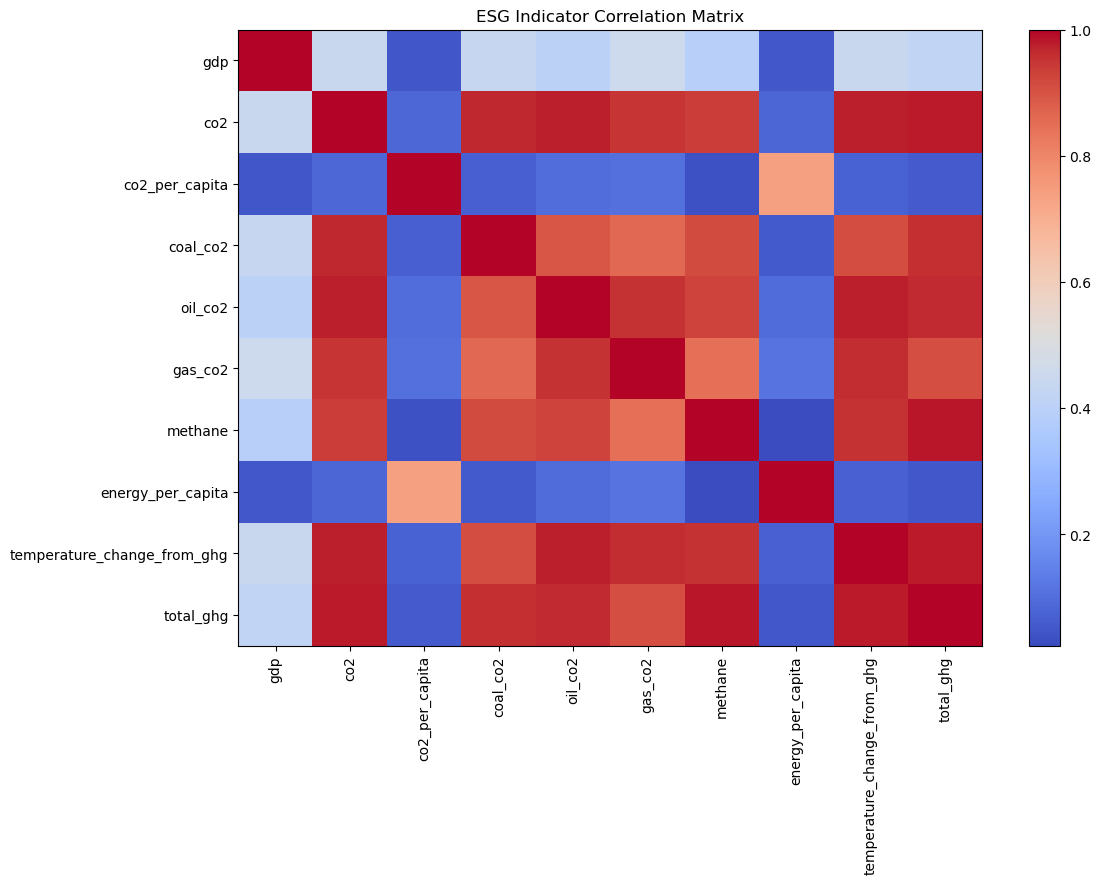

In [32]:
plt.figure(figsize=(12,8))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(
    'ESG Indicator Correlation Matrix'
)

plt.show()

### Key Insight

Correlation analysis revealed several strong relationships among environmental and sustainability indicators.

Major findings include:
- total greenhouse gas emissions exhibit extremely strong correlation with CO2 emissions
- fossil fuel emission sources (coal, oil, and gas) are highly associated with total environmental impact
- methane emissions demonstrate strong linkage with greenhouse gas intensity
- temperature change indicators are closely related to rising emissions

The analysis also indicates:
- energy consumption per capita is strongly associated with carbon intensity per person
- GDP shows moderate positive correlation with environmental impact metrics

These findings suggest that:
- fossil fuel dependency remains a primary driver of climate-related ESG risk
- greenhouse gas accumulation is closely connected to industrial energy systems
- sustainability strategies should focus on reducing fossil fuel intensity and improving energy efficiency

The correlation structure provides a strong analytical foundation for ESG risk scoring and sustainability intelligence modeling.

## Step 19 — Develop ESG Risk Scoring Model

A custom ESG risk-scoring framework was developed to quantify environmental sustainability risk across countries.

The scoring model combines multiple environmental indicators to create a unified sustainability risk metric.

The model incorporates:
- carbon emissions
- methane emissions
- energy intensity
- climate impact indicators

The objective is to transform raw environmental data into actionable ESG intelligence suitable for:
- sustainability benchmarking
- country-level risk classification
- executive reporting
- ESG dashboard analytics

## Step 20 — Normalize ESG Risk Indicators

Selected ESG indicators were normalized using Min-Max scaling to ensure consistent weighting across variables with different numerical ranges.

In [33]:
risk_cols = [
    'co2',
    'methane',
    'energy_per_capita',
    'temperature_change_from_ghg'
]

normalized_df = esg_df.copy()

for col in risk_cols:
    
    normalized_df[col + '_normalized'] = (
        (normalized_df[col] - normalized_df[col].min())
        /
        (normalized_df[col].max() - normalized_df[col].min())
    )

In [34]:
normalized_df.head()

,country,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,energy_per_capita,share_global_co2,temperature_change_from_ghg,total_ghg,co2_normalized,methane_normalized,energy_per_capita_normalized,temperature_change_from_ghg_normalized
0,Afghanistan,1950,7776180.0,9.421400e+09,0.084,0.011,0.021,0.063,0.0,7.879,481.209,0.001,0.001,19.869,0.000002,0.000829,0.001511,0.001191
1,Afghanistan,1951,7879343.0,9.692280e+09,0.092,0.012,0.026,0.066,0.0,7.973,481.209,0.001,0.001,21.069,0.000002,0.000839,0.001511,0.001191
2,Afghanistan,1952,7987784.0,1.001732e+10,0.092,0.011,0.032,0.060,0.0,8.073,481.209,0.001,0.001,22.094,0.000002,0.000850,0.001511,0.001191
3,Afghanistan,1953,8096703.0,1.063052e+10,0.106,0.013,0.038,0.068,0.0,8.186,481.209,0.002,0.001,23.256,0.000003,0.000862,0.001511,0.001191
4,Afghanistan,1954,8207954.0,1.086636e+10,0.106,0.013,0.043,0.064,0.0,8.305,481.209,0.002,0.001,24.251,0.000003,0.000874,0.001511,0.001191


## Step 21 — Construct ESG Risk Score

A weighted ESG risk-scoring model was developed using normalized environmental indicators.

The scoring framework assigns relative importance to:
- CO2 emissions
- methane emissions
- energy intensity
- climate impact

Weighted scoring enables:
- sustainability benchmarking
- country-level ESG risk evaluation
- environmental intelligence reporting
- executive-level ESG analytics

In [35]:
normalized_df['esg_risk_score'] = (

    0.40 * normalized_df['co2_normalized']
    
    + 0.25 * normalized_df['methane_normalized']
    
    + 0.20 * normalized_df[
        'energy_per_capita_normalized'
    ]
    
    + 0.15 * normalized_df[
        'temperature_change_from_ghg_normalized'
    ]
)

## Step 22 — Validate ESG Risk Score Distribution

The ESG risk-score distribution was analyzed to evaluate:
- scoring consistency
- sustainability variation
- environmental risk spread across countries

In [36]:
normalized_df['esg_risk_score'].describe()

count    15045.000000
mean         0.023312
std          0.051967
min          0.000090
25%          0.002055
50%          0.008062
75%          0.024129
max          0.813595
Name: esg_risk_score, dtype: float64

## Step 23 — Visualize ESG Risk Distribution

A distribution analysis was performed to evaluate the spread of sustainability risk scores across the ESG dataset.

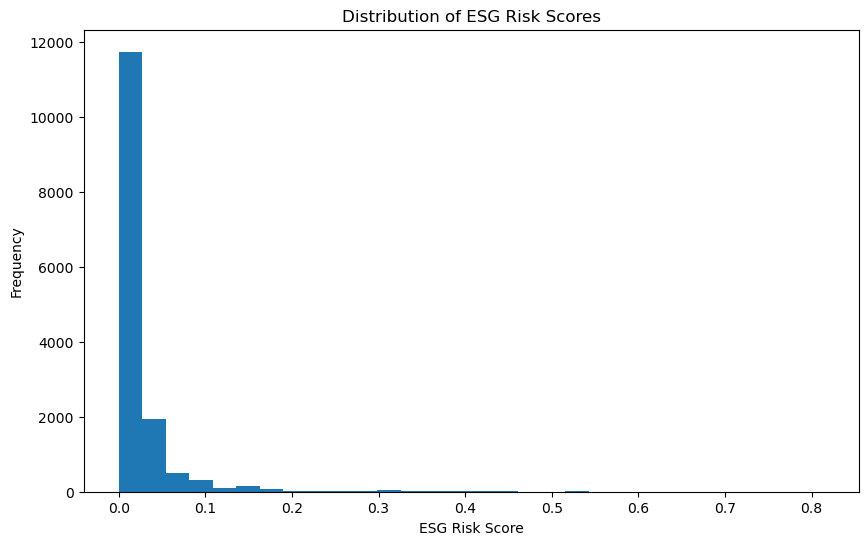

In [38]:
plt.figure(figsize=(10,6))

plt.hist(
    normalized_df['esg_risk_score'],
    bins=30
)

plt.title(
    'Distribution of ESG Risk Scores'
)

plt.xlabel('ESG Risk Score')
plt.ylabel('Frequency')

plt.show()

### Key Insight

The ESG risk-score distribution indicates that environmental risk is unevenly distributed across global economies.

Major observations include:
- most country-year observations fall within low-to-moderate risk ranges
- a smaller group of economies exhibits significantly elevated sustainability risk scores
- high-risk observations likely correspond to heavily industrialized or fossil-fuel-dependent economies

The distribution suggests that:
- environmental impact is concentrated among a limited number of high-emission economies
- sustainability transition risks are not evenly shared globally
- ESG-focused policy interventions may need to prioritize high-risk regions and industries

The scoring framework successfully transforms environmental indicators into interpretable ESG intelligence metrics.

## Step 24 — Develop ESG Risk Categories

The continuous ESG risk score was transformed into categorical sustainability risk levels.

Quantile-based classification was used to create:
- Low Risk
- Medium Risk
- High Risk

This approach improves interpretability and supports:
- ESG benchmarking
- executive reporting
- sustainability segmentation
- dashboard intelligence

In [39]:
normalized_df['risk_category'] = pd.qcut(
    normalized_df['esg_risk_score'],
    
    q=3,
    
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk'
    ]
)

## Step 25 — Validate ESG Risk Classification

The distribution of ESG risk categories was evaluated to confirm balanced sustainability segmentation across the dataset.

In [40]:
normalized_df['risk_category'].value_counts()

risk_category
Low Risk       5015
Medium Risk    5015
High Risk      5015
Name: count, dtype: int64

## Step 26 — Visualize ESG Risk Segmentation

A categorical distribution analysis was conducted to evaluate the proportion of observations across ESG risk levels.

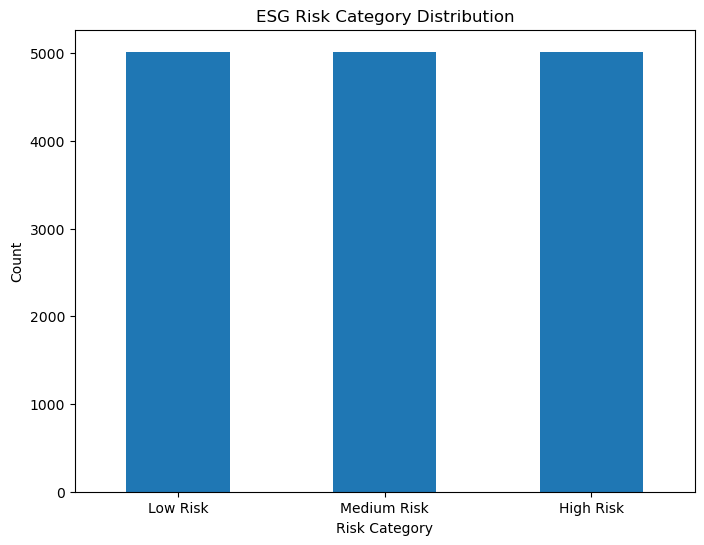

In [42]:
risk_counts = (
    normalized_df['risk_category']
    .value_counts()
)

plt.figure(figsize=(8,6))

risk_counts.plot(kind='bar')

plt.title(
    'ESG Risk Category Distribution'
)

plt.xlabel('Risk Category')
plt.ylabel('Count')

plt.xticks(rotation=0)

plt.show()

### Key Insight

The ESG risk-classification framework successfully segmented the dataset into balanced sustainability risk categories.

Quantile-based classification ensured:
- consistent category distribution
- improved comparative analysis
- robust sustainability benchmarking

The resulting segmentation supports:
- country-level ESG evaluation
- executive sustainability reporting
- dashboard-driven environmental intelligence
- comparative risk assessment across economies

The classification framework transforms complex environmental indicators into interpretable ESG risk categories suitable for business and policy analysis.

## Step 27 — Identify Highest ESG Risk Countries

Average ESG risk scores were aggregated at the country level to identify economies exhibiting the highest long-term environmental sustainability risk.

The original dataset contains:
- countries
- regional aggregates
- income classifications
- global summary groups

To ensure analytical accuracy, non-country aggregate entities were excluded before generating ESG risk rankings.

This analysis supports:
- sustainability benchmarking
- environmental risk prioritization
- ESG intelligence reporting
- executive-level sustainability assessment

In [47]:
exclude_regions = [
    'World',
    'Asia',
    'Europe',
    'North America',
    'South America',
    'Africa',
    'European Union (27)',
    'High-income countries',
    'Upper-middle-income countries',
    'Lower-middle-income countries',
    'Low-income countries'
]

country_risk_df = normalized_df[
    ~normalized_df['country'].isin(
        exclude_regions
    )
]

top_risk_countries = (

    country_risk_df.groupby('country')[
        'esg_risk_score'
    ]

    .mean()

    .sort_values(ascending=False)

    .head(10)
)

top_risk_countries

country
United States           0.138833
Qatar                   0.096732
Bahrain                 0.084802
China                   0.075323
United Arab Emirates    0.072776
Russia                  0.071527
Canada                  0.071232
Kuwait                  0.069633
Brunei                  0.069332
Luxembourg              0.064974
Name: esg_risk_score, dtype: float64

## Step 28 — Visualize Highest ESG Risk Countries

A comparative visualization was created to identify countries exhibiting the highest average ESG sustainability risk scores.

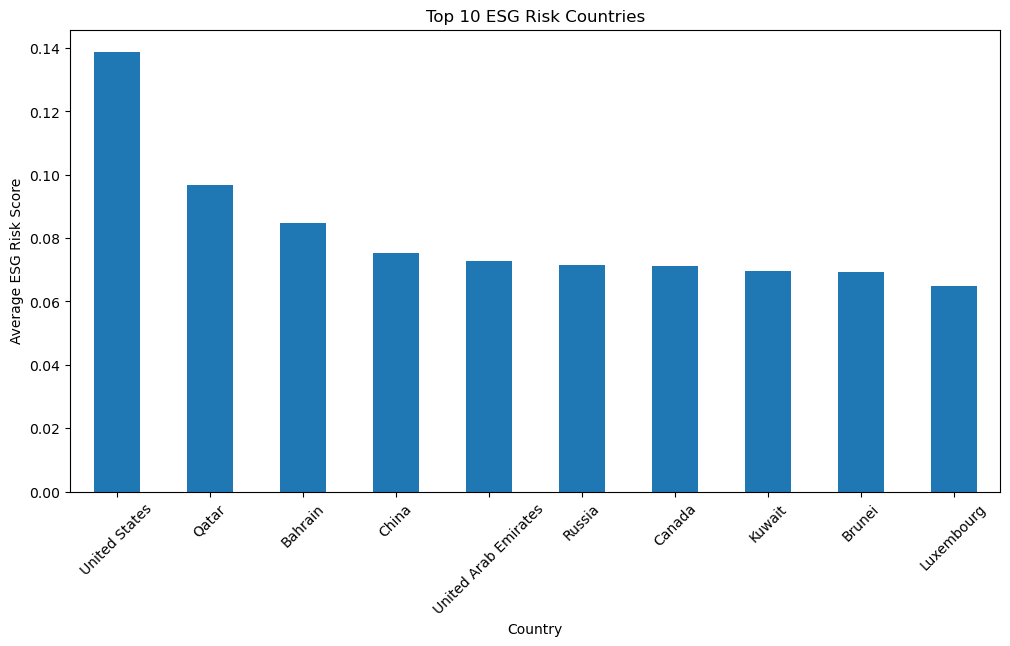

In [49]:
plt.figure(figsize=(12,6))

top_risk_countries.plot(kind='bar')

plt.title(
    'Top 10 ESG Risk Countries'
)

plt.xlabel('Country')
plt.ylabel('Average ESG Risk Score')

plt.xticks(rotation=45)

plt.show()

### Key Insight

The ESG risk ranking highlights countries exhibiting consistently elevated long-term environmental sustainability risk.

Major observations include:
- fossil-fuel-dependent economies demonstrate higher ESG risk exposure
- high energy-intensity countries show elevated environmental pressure
- industrialized economies maintain strong long-term climate impact patterns

The findings suggest that:
- carbon-intensive development models increase sustainability transition risk
- economies heavily dependent on fossil fuels may face stronger regulatory and climate-related pressures
- ESG intelligence can support sustainability benchmarking and environmental policy prioritization

The ranking framework provides an interpretable country-level sustainability risk assessment suitable for executive ESG reporting and comparative environmental analysis.

## Step 29 — Develop ESG Executive KPI Summary

Executive-level ESG KPIs were generated to support:
- sustainability reporting
- environmental intelligence dashboards
- executive monitoring
- high-level ESG decision support

The KPI framework summarizes critical environmental and sustainability indicators across the ESG dataset.

In [50]:
total_countries = (
    country_risk_df['country']
    .nunique()
)

average_risk_score = (
    country_risk_df[
        'esg_risk_score'
    ].mean()
)

highest_risk_country = (
    top_risk_countries.index[0]
)

average_co2 = (
    country_risk_df['co2']
    .mean()
)

average_ghg = (
    country_risk_df['total_ghg']
    .mean()
)

print(
    f"Total Countries Analyzed: {total_countries}"
)

print(
    f"Average ESG Risk Score: {average_risk_score:.4f}"
)

print(
    f"Highest ESG Risk Country: {highest_risk_country}"
)

print(
    f"Average CO2 Emissions: {average_co2:.2f}"
)

print(
    f"Average Total GHG Emissions: {average_ghg:.2f}"
)

Total Countries Analyzed: 197
Average ESG Risk Score: 0.0159
Highest ESG Risk Country: United States
Average CO2 Emissions: 112.30
Average Total GHG Emissions: 194.80


### Key Insight

The executive ESG KPI framework provides a high-level summary of global environmental sustainability performance.

Major findings include:
- 197 countries were analyzed across environmental and climate-related indicators
- the United States exhibited the highest long-term ESG risk score based on the weighted sustainability model
- average ESG risk levels remained relatively low across the full dataset, while a smaller group of economies demonstrated significantly elevated environmental impact

The KPI framework enables:
- executive-level sustainability monitoring
- dashboard-driven ESG reporting
- country-level environmental benchmarking
- high-level climate risk evaluation

## Step 30 — Develop ESG Benchmarking Table

A country-level ESG benchmarking table was developed to consolidate:
- sustainability risk scores
- ESG risk categories
- environmental indicators
- greenhouse gas metrics

The benchmarking framework supports:
- comparative sustainability analysis
- dashboard intelligence
- country-level ESG reporting
- executive benchmarking workflows

In [51]:
benchmark_table = (

    country_risk_df.groupby('country')
    
    .agg({
        'esg_risk_score': 'mean',
        'risk_category': lambda x: x.mode()[0],
        'co2': 'mean',
        'total_ghg': 'mean',
        'energy_per_capita': 'mean'
    })

    .reset_index()
)

benchmark_table.head()

,country,esg_risk_score,risk_category,co2,total_ghg,energy_per_capita
0,Afghanistan,0.000928,Low Risk,3.234947,22.970160,706.396520
1,Albania,0.007344,Medium Risk,4.010280,9.814120,11356.200293
2,Algeria,0.007823,Medium Risk,72.923640,129.578560,8682.392960
3,Angola,0.002674,Low Risk,9.861187,106.790947,2195.520107
4,Antigua and Barbuda,0.017855,Medium Risk,0.358987,0.380827,28288.180507


## Step 31 — Rank Countries by ESG Risk

Countries were ranked according to average ESG sustainability risk scores to support environmental benchmarking and executive analysis.

In [52]:
benchmark_table = (
    
    benchmark_table
    
    .sort_values(
        by='esg_risk_score',
        ascending=False
    )
)

benchmark_table.head(10)

,country,esg_risk_score,risk_category,co2,total_ghg,energy_per_capita
188,United States,0.138833,High Risk,4603.267520,5841.368893,83471.598387
142,Qatar,0.096732,High Risk,34.541560,47.128800,152757.445760
12,Bahrain,0.084802,High Risk,14.214627,30.077360,133936.061800
36,China,0.075323,High Risk,3771.929573,5370.908880,10356.278080
186,United Arab Emirates,0.072776,High Risk,88.246045,108.758106,113310.683833
144,Russia,0.071527,High Risk,1553.904533,2374.878400,61358.225213
31,Canada,0.071232,High Risk,417.227280,766.641800,98945.402360
93,Kuwait,0.069633,High Risk,51.537627,82.272867,108405.101773
25,Brunei,0.069332,High Risk,5.270000,7.847747,110138.337053
102,Luxembourg,0.064974,High Risk,10.437547,11.307587,103149.636653


### Key Insight

The ESG benchmarking framework identified several economies with consistently elevated long-term sustainability risk exposure.

Major observations include:
- highly industrialized economies exhibit significant environmental pressure due to large-scale carbon emissions
- fossil-fuel-dependent countries demonstrate elevated energy intensity and climate-related risk
- countries with extremely high energy consumption per capita generally show increased ESG risk exposure

The analysis indicates that:
- energy-intensive economic models contribute strongly to sustainability risk
- fossil fuel dependency remains a major environmental challenge
- long-term ESG risk is influenced by both industrial emissions and resource consumption patterns

The benchmarking table provides a structured sustainability intelligence framework suitable for:
- ESG dashboards
- executive reporting
- environmental benchmarking
- comparative climate-risk analysis

## Step 32 — Export ESG Intelligence Dataset

The final ESG intelligence dataset was exported for:
- SQL analytics
- dashboard development
- sustainability reporting
- executive ESG intelligence workflows

The exported dataset consolidates:
- ESG risk scores
- sustainability categories
- environmental indicators
- benchmarking metrics

In [53]:
benchmark_table.to_csv(
    'esg_benchmarking_dataset.csv',
    index=False
)


In [54]:
normalized_df.to_csv(
    'final_esg_analytics_dataset.csv',
    index=False
)

# EDA Conclusion

The exploratory analysis successfully transformed environmental and sustainability data into actionable ESG intelligence.

Major analytical outcomes included:
- identification of major carbon-emitting economies
- long-term emission trend analysis
- fossil fuel dependency evaluation
- greenhouse gas impact assessment
- sustainability intensity benchmarking
- ESG risk-score development
- country-level environmental risk classification

The analysis demonstrated strong relationships between:
- industrial activity
- fossil fuel consumption
- greenhouse gas accumulation
- climate-related sustainability risk

A custom ESG risk-scoring framework was developed to support:
- sustainability benchmarking
- executive ESG reporting
- dashboard intelligence
- environmental risk prioritization

The final benchmarking dataset provides a structured analytical foundation for:
- SQL business analysis
- Power BI dashboard development
- sustainability intelligence reporting
- ESG-focused business decision support